In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [21]:
threshold = '0.8'

def get_K(Qfile):
    match = re.search(r'K\.(\d+)\.Major', Qfile)
    if match: 
        return "K="+str(match.group(1))
    else:
        return ""

       
def plot_Q(Qfiles):
    # Create a 3x2 subplot layout
    fig, axes = plt.subplots(3,5, figsize=(16,9))
    
    for Qfile, ax in zip(Qfiles, axes.flatten()):
        matrix = np.loadtxt(Qfile)

        # Calculate the maximum coefficient values for each individual
        max_coefficients = np.max(matrix, axis=1)
        
        # Count individuals with max coefficients higher than 0.8
        count_above_threshold = np.sum(max_coefficients >= float(threshold))
        
        # Get the index of the maximum value (column number)
        col_number_max_coefficient = np.argmax(matrix, axis=1)
        
        # Get unique column numbers
        unique_col_numbers = len(np.unique(col_number_max_coefficient))
        
        # Create a kernel density estimate (KDE) for the maximum coefficient values
        kde = gaussian_kde(max_coefficients)

        # Generate x values for the density plot
        x_values = np.linspace(0, 1, 100)

        # Add a vertical line at x= threshold
        ax.axvline(x=float(threshold), color='black', linestyle='--', label='Threshold='+threshold)
        
        # Set the y-axis limits
        ax.set_ylim(0,10)


        # Plot the density
        if get_K(Qfile) == bestK:
            ax.plot(x_values, kde(x_values), label='Density', color='#F57C00')  # emphasize line for "K=11"
        else:
            ax.plot(x_values, kde(x_values), label='Density')

        ax.set_title(f'''{get_K(Qfile)}
PureSamples={str(count_above_threshold)} 
MainClusters={str(unique_col_numbers)}''')
        ax.set_xlabel('Max Membership Coefficient')
        ax.set_ylabel('Density of Individuals')
        ax.legend()
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.savefig(f's00.density_plot.{batch}.png')
    plt.show()
   

OSError: [WinError 1005] The volume does not contain a recognized file system.
Please make sure that all required file system drivers are loaded and that the volume is not corrupted: 'Z:\\run_Choose_nonAdmix_split_by_pop\\bin'

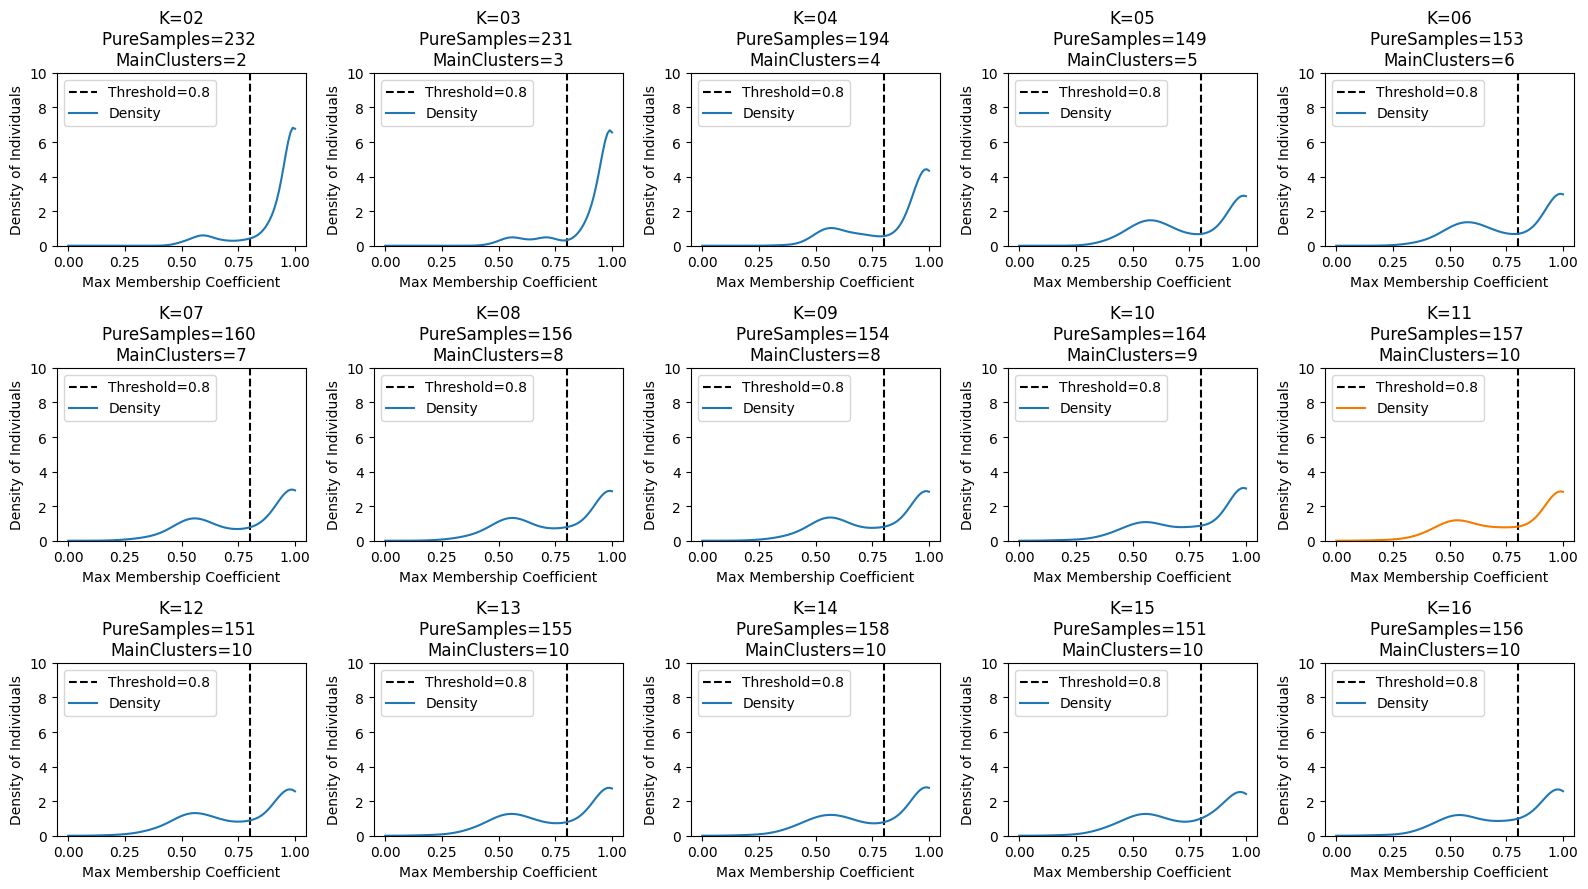

In [9]:
batch = 'branch15.batch30.noclone'
batch = 'branch15.batch27.Europe/'
batch = 'branch15.batch31.Asia'

Qfiles=[f"../input/{batch}/K."+ str('{:02d}'.format(i)) +".MajorCluster.Q" for i in range(2,17) ]

bestK = 'K=11'
plot_Q(Qfiles)
